Imports

In [34]:
import time
from typing import Dict, List

import torch
import torch.nn as nn
import os
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms

Load Dataset

In [35]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

True
0
NVIDIA T1200 Laptop GPU


In [36]:
from torchvision import datasets, transforms

data_path = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
base_dataset = datasets.ImageFolder(root=data_path, transform=transform)

print(len(base_dataset.classes))  # should be 45
print(base_dataset.classes[:5])

45
['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach']


## Dataset Preparation

### 1.transforms

In [37]:
def get_resisc45_transforms(img_size=224, augment=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]) if augment else transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_tf, val_tf

### 2.DataLoader setup

In [38]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)

In [39]:
def get_dataloaders(data_root, img_size=224, batch_size=24):

    train_tf, val_tf = get_resisc45_transforms(img_size)

    base_dataset = datasets.ImageFolder(root=data_root)

    n_total = len(base_dataset)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val

    train_ds, val_ds, test_ds = random_split(
        base_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    train_ds = TransformSubset(train_ds, train_tf)
    val_ds   = TransformSubset(val_ds, val_tf)
    test_ds  = TransformSubset(test_ds, val_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

## Architechture

### 1.BasicBlock (ResNet building block)


In [40]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1  = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out

### 2.ResNet18 Model

In [81]:
class ResNet18(nn.Module):

    def __init__(self, num_classes: int = 45, in_channels: int = 3, dropout_p: float = 0.3):
        super().__init__()

        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool    = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout    = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(512, num_classes)

        self._init_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        blocks = []
        blocks.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x
    
model = ResNet18(num_classes=45)
print(model)

ResNet18(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): 

## Training Functions

In [82]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):

    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True, dtype=torch.float32)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # -----------------------------
        # FORWARD PASS
        # -----------------------------
        logits = model(images)
        loss = criterion(logits, labels)

        # safety check (prevents NaN explosion)
        if torch.isnan(loss):
            print("NaN loss detected, skipping batch")
            continue

        # -----------------------------
        # BACKWARD PASS
        # -----------------------------
        loss.backward()

        # gradient clipping (stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # -----------------------------
        # METRICS
        # -----------------------------
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += images.size(0)

    return {
        "loss": total_loss / total,
        "acc": correct / total
    }

### Evaluate

In [83]:
# -------------------------------
# Evaluation
# -------------------------------
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return {
        "loss": total_loss / total,
        "acc": correct / total
    }

### Full trainning loop

In [84]:
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 50,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    save_path: str = "resnet18_scratch_best.pth",
    device_str: str = "auto",
):

    device = (
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if device_str == "auto"
        else torch.device(device_str)
    )

    print(f"Training on: {device}")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0
    patience_ctr = 0
    patience = 15

    history = []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_stats = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_stats = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step()

        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']

        history.append({
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_acc": train_stats["acc"],
            "val_loss": val_stats["loss"],
            "val_acc": val_stats["acc"],
            "lr": lr_now,
        })

        print(
            f"Epoch {epoch:3d}/{num_epochs}  "
            f"train_loss={train_stats['loss']:.4f}  train_acc={train_stats['acc']:.4f}  "
            f"val_loss={val_stats['loss']:.4f}  val_acc={val_stats['acc']:.4f}  "
            f"lr={lr_now:.6f}  ({elapsed:.1f}s)"
        )

        # Save best model
        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]

            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_acc": best_val_acc,
            }, save_path)

            print(f"  Saved best model  val_acc={best_val_acc:.4f}")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping triggered after {epoch} epochs.")
                break

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    return history

In [85]:

# GPU Diagnostic Cell
import torch
print("=== GPU DIAGNOSTIC ===")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
print(f"Current CUDA device: {torch.cuda.current_device()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

# Test GPU execution
test_tensor = torch.randn(1000, 1000).cuda()
result = torch.matmul(test_tensor, test_tensor)
print(f"Test tensor on device: {test_tensor.device}")
print(f"GPU computation works: {result.device}")
print("=== END DIAGNOSTIC ===\n")


=== GPU DIAGNOSTIC ===
CUDA available: True
CUDA device count: 1
Current CUDA device: 0
GPU name: NVIDIA T1200 Laptop GPU
Test tensor on device: cuda:0
GPU computation works: cuda:0
=== END DIAGNOSTIC ===



### Training execution

Dataset has 45 classes

1. SAMPLE IMAGES FROM DATASET


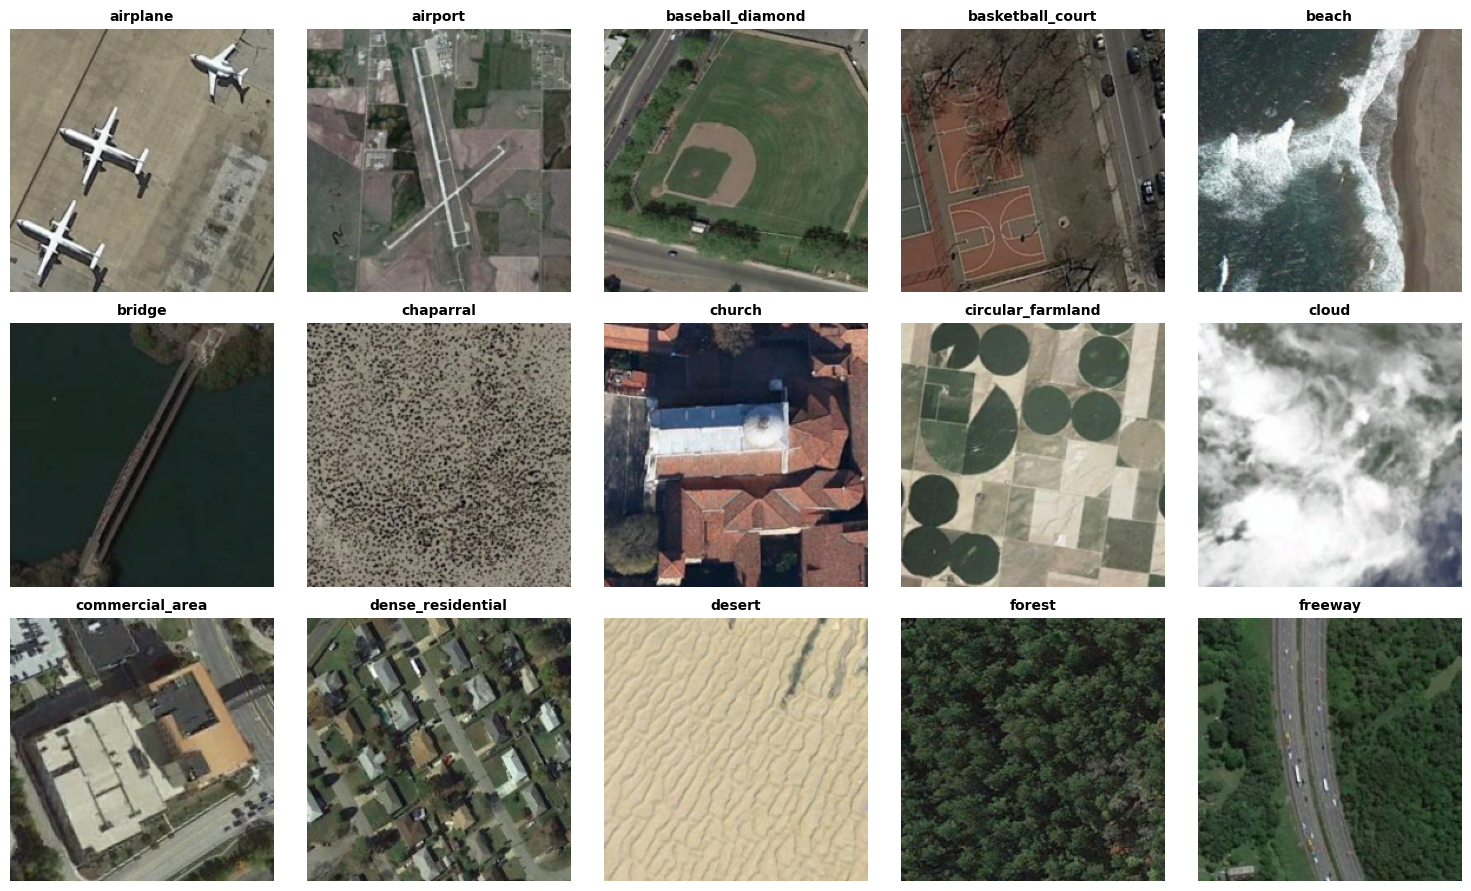

✓ Displayed sample images from 15 classes

2. CLASS DISTRIBUTION


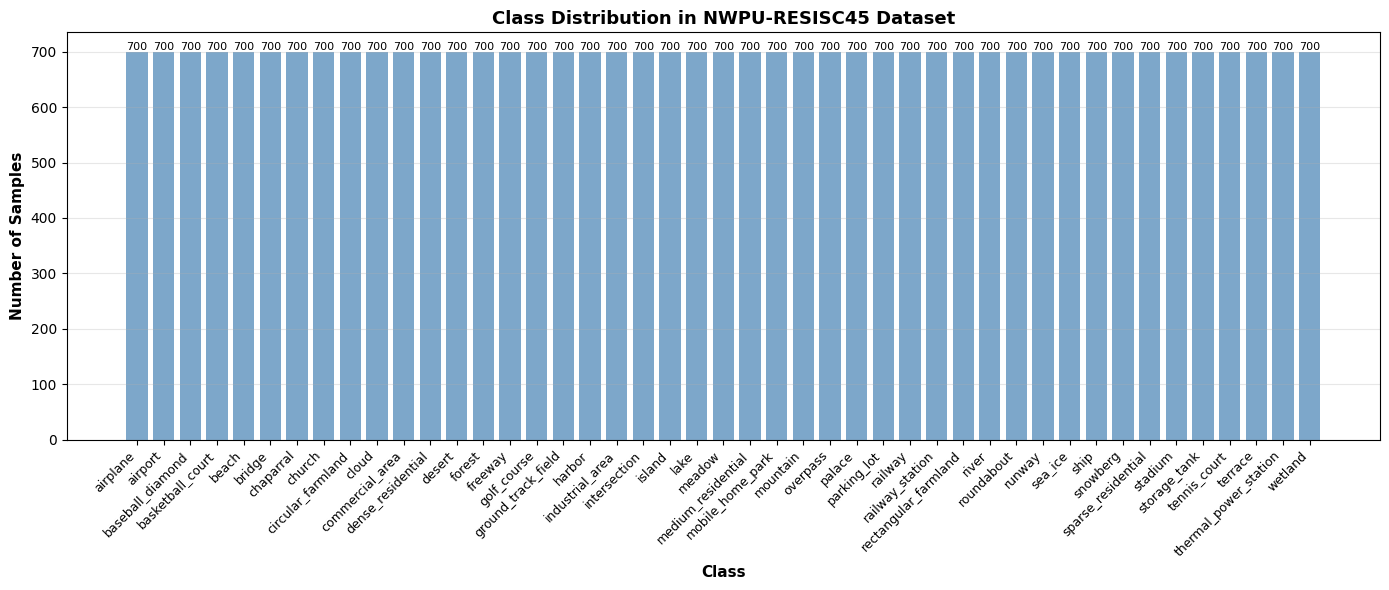

✓ Class distribution plotted
  Total samples: 31500
  Samples per class (avg): 700.0
  Min samples: 700, Max samples: 700

3. TRAINING BATCH VISUALIZATION


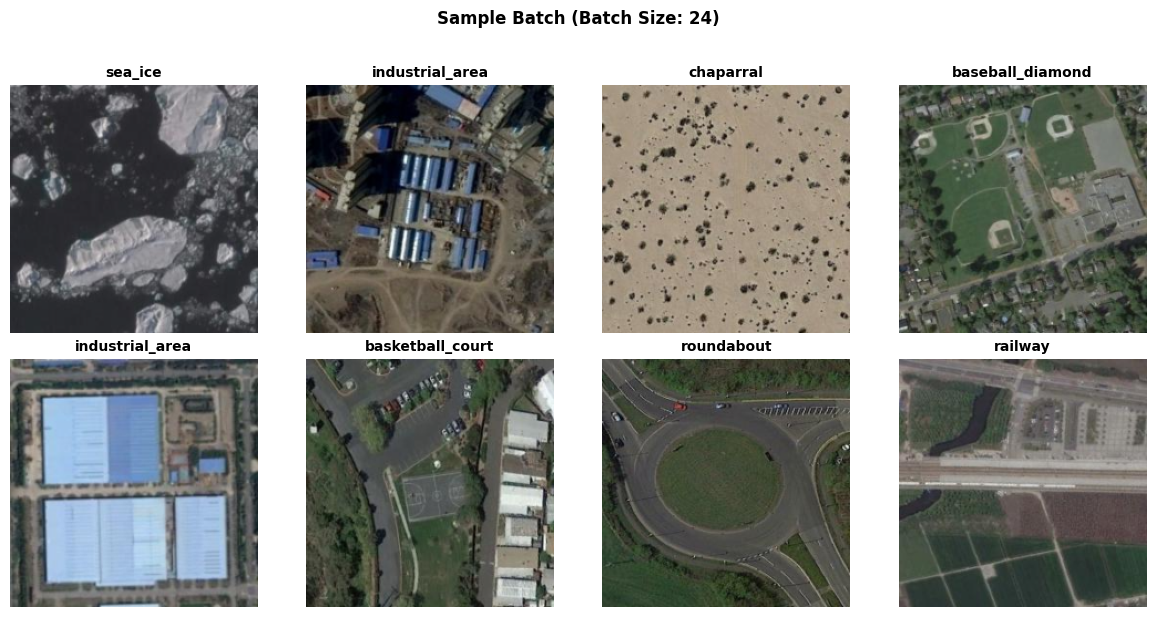

✓ Batch visualization complete
  Batch size: 24
  Image shape per sample: torch.Size([3, 224, 224])

DATASET READY FOR TRAINING ✓



In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np

# ====================================
# VISUALIZATION BEFORE TRAINING
# ====================================

# Get class names and create mappings
class_names = base_dataset.classes
num_classes = len(class_names)
print(f"Dataset has {num_classes} classes")

# 1. Show sample images from different classes
print("\n" + "="*50)
print("1. SAMPLE IMAGES FROM DATASET")
print("="*50)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

# Get one sample per class (for first 15 classes)
class_samples = {}
for idx, (img, label) in enumerate(base_dataset):
    if label not in class_samples:
        class_samples[label] = (img, label)
    if len(class_samples) == 15:
        break

# Plot samples
for plot_idx, (class_idx, (img, label)) in enumerate(sorted(class_samples.items())):
    ax = axes[plot_idx]
    # Denormalize image for visualization
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    
    ax.imshow(img_np)
    ax.set_title(class_names[label], fontsize=10, fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for idx in range(plot_idx + 1, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Displayed sample images from {len(class_samples)} classes")

# 2. Show class distribution
print("\n" + "="*50)
print("2. CLASS DISTRIBUTION")
print("="*50)

class_counts = Counter([label for _, label in base_dataset])
class_counts = dict(sorted(class_counts.items()))

fig, ax = plt.subplots(figsize=(14, 6))
classes_list = [class_names[i] for i in sorted(class_counts.keys())]
counts_list = [class_counts[i] for i in sorted(class_counts.keys())]

bars = ax.bar(range(len(classes_list)), counts_list, color='steelblue', alpha=0.7)
ax.set_xlabel('Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution in NWPU-RESISC45 Dataset', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(classes_list)))
ax.set_xticklabels(classes_list, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Class distribution plotted")
print(f"  Total samples: {len(base_dataset)}")
print(f"  Samples per class (avg): {len(base_dataset) / num_classes:.1f}")
print(f"  Min samples: {min(counts_list)}, Max samples: {max(counts_list)}")

# 3. Show batch visualization
print("\n" + "="*50)
print("3. TRAINING BATCH VISUALIZATION")
print("="*50)

# Get a batch from train_loader
train_loader_temp, _, _ = get_dataloaders(data_path)
batch_images, batch_labels = next(iter(train_loader_temp))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx in range(min(8, batch_images.shape[0])):
    ax = axes[idx]
    img = batch_images[idx].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.set_title(class_names[batch_labels[idx].item()], fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Sample Batch (Batch Size: {batch_images.shape[0]})', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batch_sample.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Batch visualization complete")
print(f"  Batch size: {batch_images.shape[0]}")
print(f"  Image shape per sample: {batch_images.shape[1:]}")

print("\n" + "="*50)
print("DATASET READY FOR TRAINING ✓")
print("="*50 + "\n")

In [ ]:
# ===============================
# FINAL RUN CELL
# ===============================

import torch
import torch.nn as nn
import os

# -------------------------------
# SETTINGS
# -------------------------------
TRAIN = True
data_path = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"
MODEL_PATH = "resnet18_scratch_best.pth"

# -------------------------------
# DEVICE
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# MODEL
# -------------------------------
model = ResNet18().to(device)
print(f"Model on device: {next(model.parameters()).device}")

# -------------------------------
# CHECKPOINT
# -------------------------------
checkpoint_exists = os.path.exists(MODEL_PATH)

# -------------------------------
# DATA
# -------------------------------
train_loader, val_loader, test_loader = get_dataloaders(data_path)


# Test: verify first batch is on GPU
test_batch_img, test_batch_lbl = next(iter(train_loader))
test_batch_img = test_batch_img.to(device)
print(f"Test batch on device: {test_batch_img.device}")

# -------------------------------
# TRAIN OR LOAD
# -------------------------------
if TRAIN:
    print("\nStarting training...\n")

    history = train(
        model,
        train_loader,
        val_loader,
        num_epochs= 60,
        save_path=MODEL_PATH
    )

    model.eval()

else:
    if not checkpoint_exists:
        raise FileNotFoundError(f"Checkpoint not found: {MODEL_PATH}")

    print("\nLoading trained model...\n")

    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()


print("\nModel is ready ✔️")

Using device: cuda
Model on device: cuda:0
Test batch on device: cuda:0

Starting training...

Training on: cuda
Epoch   1/60  train_loss=2.6960  train_acc=0.3262  val_loss=2.4424  val_acc=0.3983  lr=0.000100  (282.5s)
  Saved best model  val_acc=0.3983
Epoch   2/60  train_loss=2.2092  train_acc=0.4820  val_loss=2.0884  val_acc=0.5236  lr=0.000100  (276.1s)
  Saved best model  val_acc=0.5236
Epoch   3/60  train_loss=1.9679  train_acc=0.5621  val_loss=1.9523  val_acc=0.5623  lr=0.000099  (271.4s)
  Saved best model  val_acc=0.5623
Epoch   4/60  train_loss=1.8113  train_acc=0.6162  val_loss=1.6646  val_acc=0.6768  lr=0.000099  (259.0s)
  Saved best model  val_acc=0.6768
Epoch   5/60  train_loss=1.6636  train_acc=0.6724  val_loss=1.6524  val_acc=0.6775  lr=0.000098  (271.5s)
  Saved best model  val_acc=0.6775
Epoch   6/60  train_loss=1.5533  train_acc=0.7074  val_loss=1.5038  val_acc=0.7331  lr=0.000098  (283.5s)
  Saved best model  val_acc=0.7331
Epoch   7/60  train_loss=1.4666  train_ac

### Evaluation (Model Metrics)

In [ ]:
# -------------------------------
# Model metrics & edge analysis
# -------------------------------

def print_model_metrics(model: nn.Module, img_size: int = 224):
    """
    Prints:
    - Total parameters
    - Trainable parameters
    - Model size (MB)
    - FLOPs (GFLOPs)

    Also provides edge-device suitability guidance.
    """

    device = next(model.parameters()).device

    # torchinfo summary (for FLOPs)
    stats = summary(
        model,
        input_size=(1, 3, img_size, img_size), #(batch=1, channels=3, height=224, width=224)
        device=device,
        verbose=0,
    )

    # Parameter counts
    total_params = sum(p.numel() for p in model.parameters()) #counts all weights and biases
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad) #Parameters that will be updated during training

    # Model size (float32 = 4 bytes per parameter)
    size_mb = total_params * 4 / (1024 ** 2)

    print(f"\n{'='*50}")
    print(f"  Total parameters  : {total_params:,}")
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Model size (FP32) : {size_mb:.2f} MB")
    print(f"  Total FLOPs       : {stats.total_mult_adds / 1e9:.2f} GFLOPs")
    print(f"{'='*50}\n")

    # Edge deployment interpretation (important for your project)
    print("Edge deployment guidance:")
    print("  - High-end phone (Snapdragon / Apple A-series): ~10–20 ms/image → OK")
    print("  - Laptop CPU (no GPU):                         ~50–150 ms/image → OK")
    print("  - Raspberry Pi 4:                              ~200–400 ms/image → borderline")
    print("  - Microcontrollers / very weak devices:        too heavy → use MobileNet")

    print(f"\nAfter INT8 quantization:")
    print(f"  - Estimated size: ~{size_mb/4:.2f} MB")
    print(f"  - ~2–3× faster CPU inference")
    print(f"  - Minimal accuracy drop (typically <1–2%)\n")

In [52]:
# -------------------------------
# TEST EVALUATION
# -------------------------------
criterion = nn.CrossEntropyLoss()

test_stats = evaluate(model, test_loader, criterion, device)

print("\n=== TEST RESULTS ===")
print(f"Test Accuracy: {test_stats['acc']:.4f}")
print(f"Test Loss    : {test_stats['loss']:.4f}")

# -------------------------------
# MODEL METRICS
# -------------------------------
print("\n=== MODEL METRICS (FP32) ===")
print_model_metrics(model)


=== TEST RESULTS ===
Test Accuracy: 0.8821
Test Loss    : 0.5438

=== MODEL METRICS (FP32) ===

  Total parameters  : 11,199,597
  Trainable params  : 11,199,597
  Model size (FP32) : 42.72 MB
  Total FLOPs       : 1.81 GFLOPs

Edge deployment guidance:
  - High-end phone (Snapdragon / Apple A-series): ~10–20 ms/image → OK
  - Laptop CPU (no GPU):                         ~50–150 ms/image → OK
  - Raspberry Pi 4:                              ~200–400 ms/image → borderline
  - Microcontrollers / very weak devices:        too heavy → use MobileNet

After INT8 quantization:
  - Estimated size: ~10.68 MB
  - ~2–3× faster CPU inference
  - Minimal accuracy drop (typically <1–2%)



### Quantize + ONNX

In [ ]:
# -------------------------------
# Quantization
# -------------------------------

def quantize_dynamic(model: nn.Module, save_path: str = "resnet18_dynamic_int8.pth") -> nn.Module:
    """
    Dynamic INT8 quantization:
    - Fast to apply
    - No calibration required
    - Quantizes only Linear layers
    - Good speedup on CPU, small accuracy drop
    """
    model_cpu = model.cpu().eval()

    quantized = torch.quantization.quantize_dynamic( #Only Linear layers are quantized
        model_cpu,
        qconfig_spec={nn.Linear},
        dtype=torch.qint8,
    )

    torch.save(quantized.state_dict(), save_path)
    print(f"Dynamic-quantized model saved -> {save_path}")

    return quantized


def quantize_static(
    model: nn.Module,
    calibration_loader: DataLoader,
    save_path: str = "resnet18_static_int8.pth",
) -> nn.Module:
    """
    Static INT8 quantization:
    - Requires calibration data
    - Quantizes Conv + Linear layers
    - Better performance gains than dynamic
    """

    model_cpu = model.cpu().eval()
    model_cpu.qconfig = torch.quantization.get_default_qconfig("x86")

    torch.quantization.prepare(model_cpu, inplace=True)

    print("Calibrating for static quantization...")
    with torch.no_grad():
        for i, (images, _) in enumerate(calibration_loader):
            model_cpu(images)
            if i >= 10:   # enough for calibration (~few hundred images)
                break

    torch.quantization.convert(model_cpu, inplace=True)

    torch.save(model_cpu.state_dict(), save_path)
    print(f"Static-quantized model saved -> {save_path}")

    return model_cpu


# -------------------------------
# ONNX Export
# -------------------------------

def export_to_onnx(model, save_path="resnet18_scratch.onnx", img_size=224, opset=17):

    model = model.cpu().eval()

    dummy_input = torch.randn(1, 3, img_size, img_size)

    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        opset_version=opset,
        input_names=["image"],
        output_names=["logits"],
        dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
        do_constant_folding=True
    )

    print("ONNX exported:", save_path)


# -------------------------------
# ONNX Validation
# -------------------------------

def validate_onnx(onnx_path: str, img_size: int = 224, num_classes: int = 45):
    """
    Validate ONNX model using ONNX Runtime
    """
    import onnxruntime as ort
    import numpy as np

    session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

    dummy = np.random.randn(1, 3, img_size, img_size).astype(np.float32)
    outputs = session.run(None, {"image": dummy})

    assert outputs[0].shape == (1, num_classes), \
        f"Unexpected output shape: {outputs[0].shape}"

    print(f"ONNX validation passed - output shape: {outputs[0].shape}")

    return outputs[0]

In [62]:
# -------------------------------
# QUANTIZATION
# -------------------------------
if "quantize_dynamic" in globals():
    print("\nApplying dynamic quantization...\n")
    q_model = quantize_dynamic(model)
    print("\n=== MODEL METRICS (INT8) ===")
    print_model_metrics(q_model)
else:
    print("\nSkipping dynamic quantization: helper cell has not been run yet.\n")



Applying dynamic quantization...

Dynamic-quantized model saved -> resnet18_dynamic_int8.pth

=== MODEL METRICS (INT8) ===

  Total parameters  : 11,176,512
  Trainable params  : 11,176,512
  Model size (FP32) : 42.64 MB
  Total FLOPs       : 1.81 GFLOPs

Edge deployment guidance:
  - High-end phone (Snapdragon / Apple A-series): ~10–20 ms/image → OK
  - Laptop CPU (no GPU):                         ~50–150 ms/image → OK
  - Raspberry Pi 4:                              ~200–400 ms/image → borderline
  - Microcontrollers / very weak devices:        too heavy → use MobileNet

After INT8 quantization:
  - Estimated size: ~10.66 MB
  - ~2–3× faster CPU inference
  - Minimal accuracy drop (typically <1–2%)



In [63]:
# -------------------------------
# ONNX EXPORT
# -------------------------------
if "export_to_onnx" in globals() and "validate_onnx" in globals():
    print("\nExporting to ONNX...\n")
    export_to_onnx(model, "resnet18_scratch.onnx")
    validate_onnx("resnet18_scratch.onnx")
else:
    print("\nSkipping ONNX export: helper cell has not been run yet.\n")

print("\nAll done ✔️")


Exporting to ONNX...

ONNX exported: resnet18_scratch.onnx
ONNX validation passed - output shape: (1, 45)

All done ✔️


Test + Export

In [64]:
# Load best model
checkpoint = torch.load("resnet18_scratch_best.pth", weights_only=False)

model = ResNet18()
model.load_state_dict(checkpoint["model_state"])

model = model.to(device)
model.eval()

# Evaluate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

test_stats = evaluate(model, test_loader, criterion, device)
print(test_stats)

# Export
export_to_onnx(model, save_path="resnet18_scratch.onnx")
validate_onnx("resnet18_scratch.onnx")

{'loss': 0.5390645956993103, 'acc': 0.8844444444444445}
ONNX exported: resnet18_scratch.onnx
ONNX validation passed - output shape: (1, 45)


array([[-1.7177007 , -1.5832374 , -1.8803759 , -1.7121745 , -0.9538983 ,
        -1.5049592 ,  2.6811862 , -1.6698427 , -1.4574248 , -1.5451474 ,
        -1.9136741 , -1.6686993 , -2.24887   , -1.4442667 , -1.3011057 ,
        -1.7393124 , -1.5907567 , -1.4806387 , -1.4592324 , -1.5866319 ,
        -1.6861556 , -1.9579711 , -1.6103868 , -1.6457698 , -1.8279793 ,
        -1.5391186 , -1.4922152 ,  1.0085926 , -1.9382042 , -0.99711084,
        -1.4287088 , -1.6109691 , -1.3445847 , -1.5828395 , -1.5856738 ,
        -1.2745417 , -1.7042639 , -1.5355954 , -0.9328261 , -1.7705795 ,
        -1.6510673 , -1.7924457 , -1.86182   , -1.902457  , -1.2075217 ]],
      dtype=float32)

In [65]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

class_names = base_dataset.classes
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def predict_onnx(onnx_path, image_path):
    session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).numpy().astype(np.float32)

    outputs = session.run(None, {"image": image})
    probs = np.exp(outputs[0]) / np.sum(np.exp(outputs[0]), axis=1, keepdims=True)

    pred = np.argmax(probs)
    conf = np.max(probs)

    return class_names[pred], float(conf)

### Sample Test Image (Saved Trained Model)
This cell loads the saved checkpoint, predicts one image from the test loader, and visualizes the result.

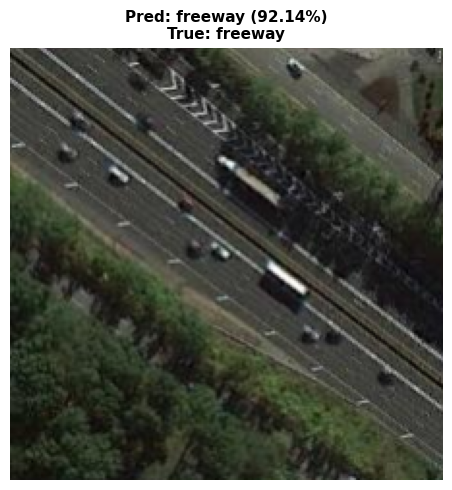

Sample test image inference complete.
Predicted class : freeway
True class      : freeway
Confidence      : 0.9214


In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Ensure class names are available
if "class_names" not in globals():
    class_names = base_dataset.classes

# Load saved trained checkpoint (best model)
MODEL_PATH = "resnet18_scratch_best.pth"
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {MODEL_PATH}")

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

# Take one sample image from test set
sample_images, sample_labels = next(iter(test_loader))
sample_idx = 22

input_tensor = sample_images[sample_idx:sample_idx + 1].to(device)
true_idx = int(sample_labels[sample_idx].item())

with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1)[0].cpu()

pred_idx = int(torch.argmax(probs).item())
confidence = float(probs[pred_idx].item())

# Denormalize image for display
img_np = sample_images[sample_idx].permute(1, 2, 0).cpu().numpy()
img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img_np)
plt.title(
    f"Pred: {class_names[pred_idx]} ({confidence:.2%})\n"
    f"True: {class_names[true_idx]}",
    fontsize=11,
    fontweight="bold"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample test image inference complete.")
print(f"Predicted class : {class_names[pred_idx]}")
print(f"True class      : {class_names[true_idx]}")
print(f"Confidence      : {confidence:.4f}")

### Post-Training Visualizations
These plots summarize training behavior and classification performance on the test set.

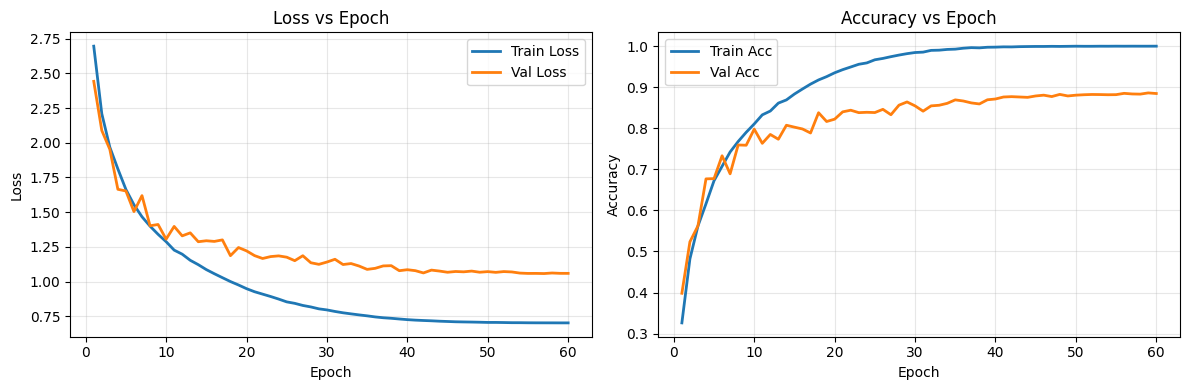

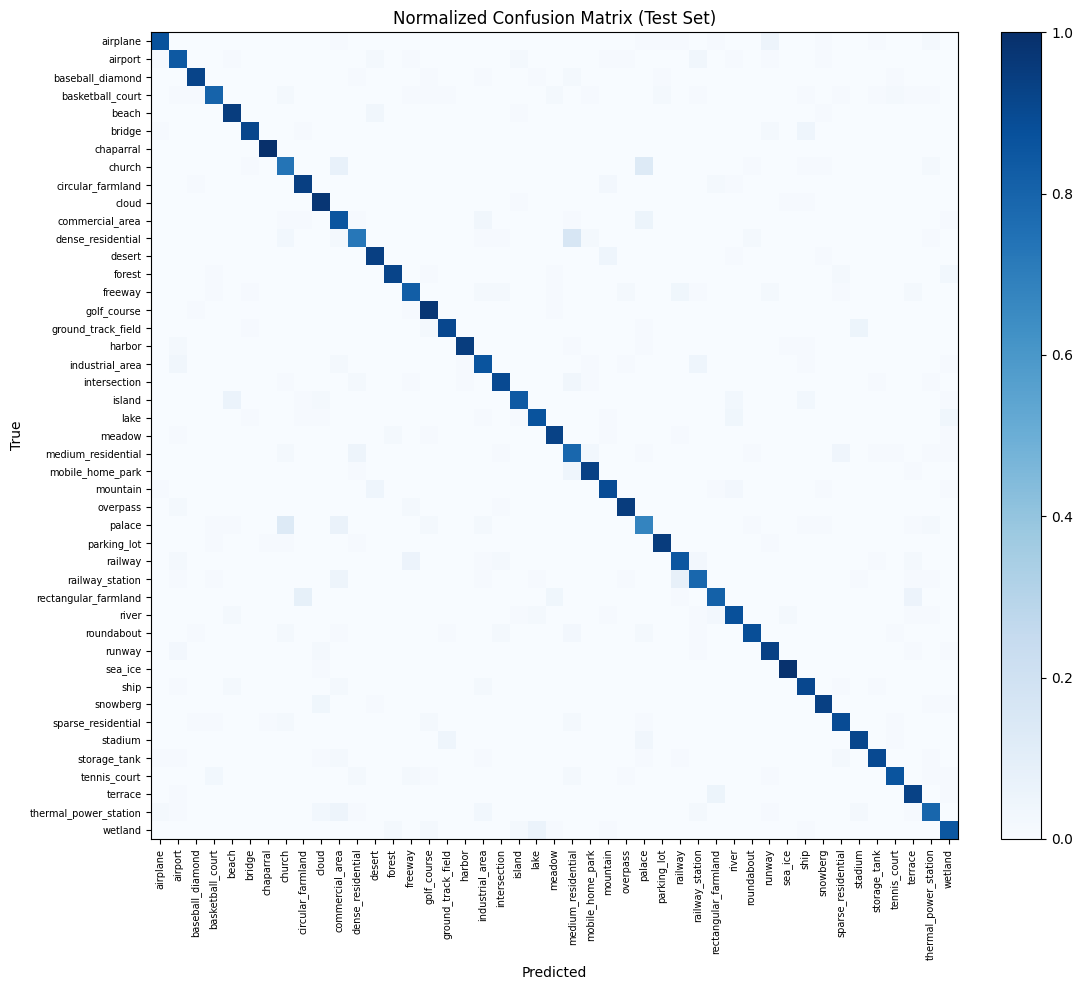

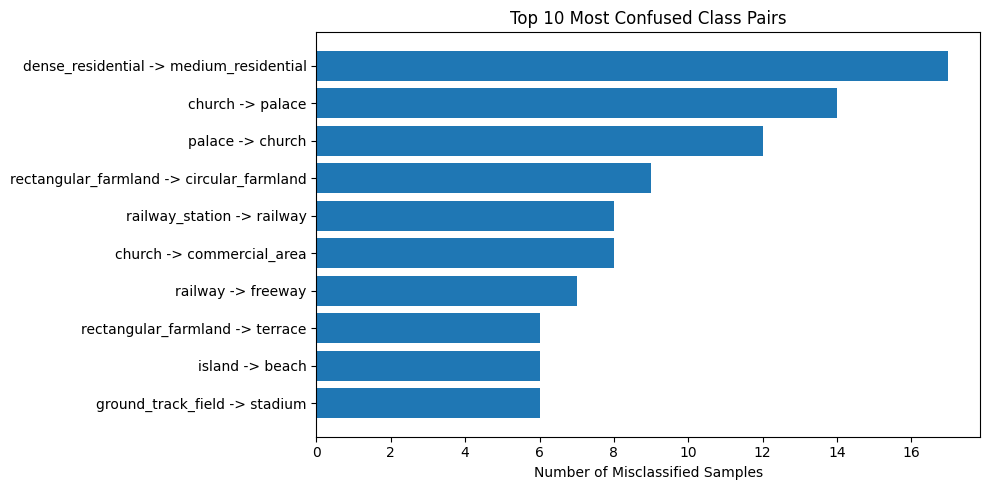

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------------------------------
# 1) Training curves (if history exists)
# ---------------------------------
if "history" in globals() and isinstance(history, list) and len(history) > 0 and isinstance(history[0], dict):
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    train_acc = [h["train_acc"] for h in history]
    val_acc = [h["val_acc"] for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_loss, label="Train Loss", linewidth=2)
    axes[0].plot(epochs, val_loss, label="Val Loss", linewidth=2)
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_acc, label="Train Acc", linewidth=2)
    axes[1].plot(epochs, val_acc, label="Val Acc", linewidth=2)
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history found. Skipping learning curves.")

# ---------------------------------
# 2) Confusion matrix on test set
# ---------------------------------
if "class_names" not in globals():
    class_names = base_dataset.classes

n_classes = len(class_names)
cm = np.zeros((n_classes, n_classes), dtype=np.int64)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        for t, p in zip(labels.cpu().numpy(), preds.cpu().numpy()):
            cm[t, p] += 1

# Normalized confusion matrix
cm_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, cmap="Blues", interpolation="nearest")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(n_classes), class_names, rotation=90, fontsize=7)
plt.yticks(range(n_classes), class_names, fontsize=7)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ---------------------------------
# 3) Top confusion pairs
# ---------------------------------
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)

flat_idx = np.argsort(off_diag, axis=None)[::-1]

pairs = []
for idx in flat_idx:
    r, c = np.unravel_index(idx, off_diag.shape)
    count = int(off_diag[r, c])
    if count > 0:
        pairs.append((r, c, count))
    if len(pairs) == 10:
        break

if len(pairs) > 0:
    labels_plot = [f"{class_names[r]} -> {class_names[c]}" for r, c, _ in pairs][::-1]
    values_plot = [v for _, _, v in pairs][::-1]

    plt.figure(figsize=(10, 5))
    plt.barh(labels_plot, values_plot)
    plt.title("Top 10 Most Confused Class Pairs")
    plt.xlabel("Number of Misclassified Samples")
    plt.tight_layout()
    plt.show()
else:
    print("No off-diagonal confusion found (perfect classification on test set).")